In [33]:
import os
import librosa
import pandas as pd
import shutil
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [30]:
sounds_df = pd.read_csv('datasets/UrbanSound8K/UrbanSound8K.csv')
sounds_df[sounds_df['classID'] == 0] 

,slice_file_name,fsID,start,end,salience,fold,classID,class
22,100852-0-0-0.wav,100852,0.0,4.0,1,5,0,air_conditioner
23,100852-0-0-1.wav,100852,0.5,4.5,1,5,0,air_conditioner
24,100852-0-0-10.wav,100852,5.0,9.0,1,5,0,air_conditioner
25,100852-0-0-11.wav,100852,5.5,9.5,1,5,0,air_conditioner
26,100852-0-0-12.wav,100852,6.0,10.0,1,5,0,air_conditioner
...,...,...,...,...,...,...,...,...
8307,85569-0-0-5.wav,85569,2.5,6.5,1,5,0,air_conditioner
8308,85569-0-0-6.wav,85569,3.0,7.0,1,5,0,air_conditioner
8309,85569-0-0-7.wav,85569,3.5,7.5,1,5,0,air_conditioner
8310,85569-0-0-8.wav,85569,4.0,8.0,1,5,0,air_conditioner


In [7]:
classes = {
    0: 'air_conditioner',
    1: 'car_horn',
    2: 'children_playing',
    3: 'dog_bark',
    4: 'drilling',
    5: 'engine_idling',
    6: 'gun_shot',
    7: 'jackhammer',
    8: 'siren',
    9: 'street_music',
}

In [ ]:
# распределение по классам
source_dir = 'datasets/UrbanSound8K/'
output_dir = 'datasets/audio/'

os.makedirs(output_dir, exist_ok=True)

folders = [f'fold{i}' for i in range(1, 11)]

for folder in folders:
    folder_path = os.path.join(source_dir, folder)
    os.makedirs(folder_path, exist_ok=True)
    for filename in os.listdir(os.path.join(source_dir, folder)):
        if filename.endswith(".wav"):
            parts = filename.replace('.wav', '').split('-')

            if len(parts) >= 2:
                class_number = parts[1]

                class_dir = os.path.join(output_dir, f'class_{class_number}')
                os.makedirs(class_dir, exist_ok=True)

                src = os.path.join(folder_path, filename)
                dst = os.path.join(class_dir, filename)
                shutil.copy2(src, dst)

In [ ]:
# обрезка полезного сигнала (удаление тишины)
def remove_silence(y, sr, top_db=25, hop_lenght=512):
    # ссигнал выше порога
    intervals = librosa.effects.split(y, top_db=top_db, hop_length=hop_lenght)
    # склейка фрагментов
    y_clean = np.concatenate([y[start:end] for start, end in intervals])
    return y_clean

path = output_dir

for fold in glob(os.path.join(path, 'class_*')):
    print(f'process folder {fold}') # debug
    for fpath in glob(os.path.join(fold, '*.wav')):
        y, sr = librosa.load(fpath, sr=None)
        y_clean = remove_silence(y, sr)

In [ ]:
# проверка распределения по классам
class_counts ={}

for class_folder in os.listdir(output_dir):
    class_path = os.path.join(output_dir, class_folder)
    count = len([f for f in os.listdir(class_path)])
    class_counts[class_folder] = count

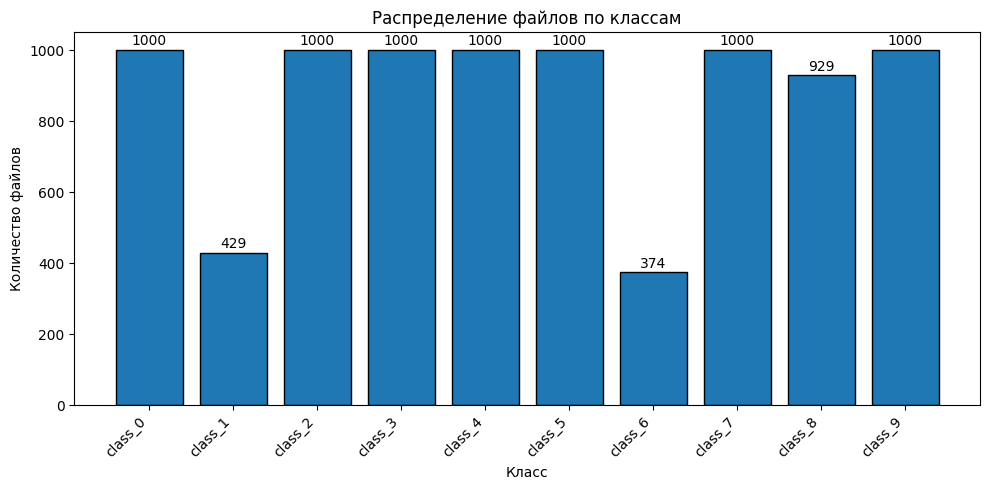

In [37]:
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, counts, edgecolor='black')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=10)
    
plt.xlabel("Класс")
plt.ylabel("Количество файлов")
plt.title("Распределение файлов по классам")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()